<a href="https://colab.research.google.com/github/babarinjayvhanlawrence-creator/Laboratory_work_3/blob/main/Activity3_Training_BABARIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Unzip the dataset into Colab
!unzip "/content/drive/My Drive/plants_Dataset.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/plants_Dataset/Caladium/000361.jpg  
  inflating: /content/plants_Dataset/Caladium/000363.jpg  
  inflating: /content/plants_Dataset/Caladium/000365.jpg  
  inflating: /content/plants_Dataset/Caladium/000367.jpg  
  inflating: /content/plants_Dataset/Caladium/000368.jpg  
  inflating: /content/plants_Dataset/Caladium/000369.jpg  
  inflating: /content/plants_Dataset/Caladium/000370.jpg  
  inflating: /content/plants_Dataset/Caladium/000372.jpg  
  inflating: /content/plants_Dataset/Caladium/000374.jpg  
  inflating: /content/plants_Dataset/Caladium/000375.jpg  
  inflating: /content/plants_Dataset/Caladium/000376.jpg  
  inflating: /content/plants_Dataset/Caladium/000377.jpg  
  inflating: /content/plants_Dataset/Caladium/000378.jpg  
  inflating: /content/plants_Dataset/Caladium/000379.jpg  
  inflating: /content/plants_Dataset/Caladium/000381.jpg  
  inflating: /content/plants_Dataset/Caladium/000382.jpg  
  inf

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive', force_remount=True)

# 2. CHECK KUNG NAA BA GYUD ANG FILE (Para sigurado)
zip_path = '/content/drive/MyDrive/plants_Dataset.zip'

if os.path.exists(zip_path):
    print("✅ Nakita nako ang Zip file! Sugdan na nako og unzip...")
    # Gamiton nato ang Python method para mas klaro ang error kung naa man
    !unzip -o -q "{zip_path}" -d /content/
    print("✅ Extraction Complete! Pwede na ka sa sunod nga cell.")
else:
    print("❌ Wala nako nakita ang file sa: " + zip_path)
    print("Palihog i-check kung husto ba ang filename sa imong Drive.")

Mounted at /content/drive
✅ Nakita nako ang Zip file! Sugdan na nako og unzip...
✅ Extraction Complete! Pwede na ka sa sunod nga cell.


In [ ]:
# 2. DATA CLEANUP (Based on your screenshots)
data_dir = "/content/plants_Dataset"
for root, dirs, files in os.walk(data_dir):
    for file in files:
        fpath = os.path.join(root, file)
        try:
            with Image.open(fpath) as img:
                img.verify()
        except:
            os.remove(fpath)

In [14]:
import pathlib
import tensorflow as tf

data_dir_path = pathlib.Path('/content/plants_Dataset')

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir_path,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(180, 180),
  batch_size=32)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir_path,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(180, 180),
  batch_size=32)

class_names = train_ds.class_names
print(f"✅ SUCCESS! Found {len(class_names)} classes: {class_names}")

Found 6532 files belonging to 20 classes.
Using 5226 files for training.
Found 6532 files belonging to 20 classes.
Using 1306 files for validation.
✅ SUCCESS! Found 20 classes: ['African_Violet', 'Air_Plant', 'Black_Bat_Flower', 'Bleeding_Heart', 'Caladium', 'Cockscomb', 'Coleus', 'Copperleaf', 'Fiddle_Leaf_Fig', 'Hydrangea', 'Jade_Vine', 'Japanese_Blood_Grass', 'Prayer_Plant', 'Purple_Fountain_Grass', 'Silver_Inch_Plant', 'Snake_Plant', 'Spathiphyllum', 'Strelitzia', 'String_of_Pearls', 'Swiss_Cheese_Plant']


In [15]:
from tensorflow.keras import layers, models
import tensorflow as tf

# 1. Define Augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# 2. Build the Improved Model with Dropout
model = models.Sequential([
  data_augmentation,
  layers.Rescaling(1./255, input_shape=(180, 180, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.3), # This helps fix the overfitting!
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.3), # Another layer for safety
  layers.Dense(len(class_names))
])

# 3. Compile
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

print("Model is ready for training!")

Model is ready for training!


In [ ]:
# 5. SAVE THE RESULT
model.save('my_plant_ai.h5')
print("Activity 3 Finished: my_plant_ai.h5 is ready.")

Activity 3 Finished: my_plant_ai.h5 is ready.


ValueError: x and y must have same first dimension, but have shapes (10,) and (15,)

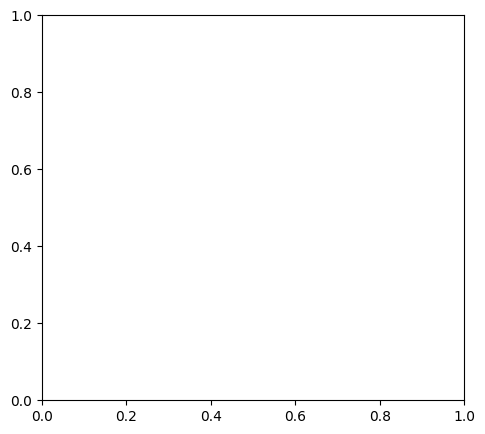

In [18]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Baseline Model: Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Baseline Model: Loss')
plt.legend()
plt.show()

In [16]:
# 4. START THE 15-EPOCH TRAINING
# This will take several minutes to finish.
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=15
)

Epoch 1/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.1923 - loss: 2.5764 - val_accuracy: 0.3645 - val_loss: 2.0946
Epoch 2/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.3574 - loss: 2.0547 - val_accuracy: 0.4403 - val_loss: 1.8892
Epoch 3/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.4357 - loss: 1.7974 - val_accuracy: 0.5199 - val_loss: 1.5869
Epoch 4/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.4912 - loss: 1.6289 - val_accuracy: 0.5444 - val_loss: 1.5796
Epoch 5/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.5346 - loss: 1.4853 - val_accuracy: 0.5444 - val_loss: 1.5536
Epoch 6/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.5710 - loss: 1.3693 - val_accuracy: 0.5919 - val_loss: 1.3772
Epoch 7/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.6010 - loss: 1.2955 - val_accuracy: 0.6118 - val_loss: 1.3082
Epoch 8/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.6267 - loss: 1.1975 - val_accu